[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AI4EPS/DAS_Seismology_Workshop/blob/main/notebooks/lab2_phasenet_das/Notebooks/lab2c_semisupervised_training.ipynb)

# Lab 2c: Semi-supervised Training

In this lab, you will learn how to:
- Understand why a general seismic model underperforms on DAS data
- Generate training labels from PhaseNet picks via pick association
- Analyze label statistics and quality
- Build training samples: waveform + Gaussian pick targets
- Configure and launch PhaseNet-DAS training

**References:**
- Zhu, W. & Beroza, G. (2019). PhaseNet: a deep-neural-network-based seismic arrival-time picking method. *GJI*.
- Zhu, W. et al. (2020). Seismic signal augmentation to improve generalization of deep neural networks. *Advances in Geophysics*, 61, 151-177.
- Zhu, W. et al. (2023). Seismic arrival-time picking on distributed acoustic sensing data using semi-supervised learning. *Nature Communications*, 14, 8192.
- Zhu, W. et al. (2025). Towards end-to-end earthquake monitoring using a multitask deep learning model. [arXiv:2506.06939](https://arxiv.org/abs/2506.06939)

---

## Setup

In [ ]:
!pip install phasenet huggingface_hub -q

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from huggingface_hub import hf_hub_download

HF_REPO = "AI4EPS/quakeflow_das"

DS = 10  # downsample factor for plotting

def plot_das(ax, arr, nx, nt, dt_s, **kwargs):
    """Plot a downsampled DAS 2D array."""
    arr = np.asarray(arr)
    ax.imshow(arr[::DS, ::DS], aspect="auto", interpolation="bilinear",
              extent=[0, nt * dt_s, nx, 0], **kwargs)

## 1. The Problem

PhaseNet (Zhu & Beroza 2019) was trained on 3-component broadband seismic data. When applied to DAS data:
- It processes each channel independently (no spatial coherence)
- It produces many false picks on noise (ocean waves, traffic, etc.)
- It misses weak events that are only visible across multiple channels

**The challenge**: we don't have manual labels for DAS data. Manual picking on thousands of channels is impractical.

**The solution**: semi-supervised learning (Zhu et al. 2023). Use PhaseNet's picks as initial pseudo-labels, filter them through association to keep only high-confidence picks, then train a DAS-specific model on these labels.

In [3]:
# Compare PhaseNet vs PhaseNet-DAS on a weak event
EVENT_ID = "20230119T202515Z"

h5_path = hf_hub_download(
    HF_REPO, f"arcata/data/{EVENT_ID}.h5", repo_type="dataset",
    local_dir="data/quakeflow_das",
)
with h5py.File(h5_path, "r") as fp:
    data = fp["data"][:]
    attrs = dict(fp["data"].attrs)

dt_s = float(attrs.get("dt_s", 0.008))
nx, nt = data.shape

# Load picks from both models
pn = pd.read_parquet(hf_hub_download(
    HF_REPO, f"arcata/phasenet/picks/{EVENT_ID}.parquet",
    repo_type="dataset", local_dir="data/quakeflow_das",
))
das = pd.read_parquet(hf_hub_download(
    HF_REPO, f"arcata/phasenet_das/picks/{EVENT_ID}.parquet",
    repo_type="dataset", local_dir="data/quakeflow_das",
))

pn_assoc = pn[pn["origin_id"] >= 0]
das_assoc = das[das["origin_id"] >= 0]

print(f"PhaseNet:     {len(pn):6d} picks, {len(pn_assoc):5d} associated")
print(f"PhaseNet-DAS: {len(das):6d} picks, {len(das_assoc):5d} associated")
print(f"\nPhaseNet produces {len(pn)} picks but NONE are associated — all false positives!")
print(f"PhaseNet-DAS finds the real event: {len(das_assoc)} associated picks.")

PhaseNet:      56358 picks,     0 associated
PhaseNet-DAS:  14614 picks,  9590 associated

PhaseNet produces 56358 picks but NONE are associated — all false positives!
PhaseNet-DAS finds the real event: 9590 associated picks.


## 2. Generate Training Labels

The key idea: use associated picks from PhaseNet as pseudo-labels for training. Association acts as a quality filter — only picks that form physically consistent P-S pairs and cluster into events survive.

Steps:
1. Run PhaseNet on all DAS events
2. Associate picks into events (Lab 2b)
3. Keep only associated picks with score above a threshold (`MIN_PROB=0.3`)
4. Save as label files

In [4]:
# Load PhaseNet picks and filter to associated picks
LABEL_EVENT = "20230106T122215Z"  # Strong event with clear arrivals

picks_path = hf_hub_download(
    HF_REPO, f"arcata/phasenet/picks/{LABEL_EVENT}.parquet",
    repo_type="dataset", local_dir="data/quakeflow_das",
)
all_picks = pd.read_parquet(picks_path)

# Filter: associated picks only + minimum score
MIN_PROB = 0.3
labels = all_picks[
    (all_picks["origin_id"] >= 0) &
    (all_picks["phase_score"] >= MIN_PROB)
].copy()

print(f"All picks: {len(all_picks)}")
print(f"Associated picks (origin_id >= 0): {(all_picks['origin_id'] >= 0).sum()}")
print(f"Labels (associated + score >= {MIN_PROB}): {len(labels)}")
print(f"  P labels: {(labels['phase_type'] == 'P').sum()}")
print(f"  S labels: {(labels['phase_type'] == 'S').sum()}")
labels.head()

All picks: 25314
Associated picks (origin_id >= 0): 6084
Labels (associated + score >= 0.3): 6084
  P labels: 3042
  S labels: 3042


,event_id,channel_index,phase_index,phase_time,phase_score,phase_type,dt_s,origin_id,origin_index,origin_time,ps_center,ps_interval
1216,20230106T122215Z,728,38649,2023-01-06T12:27:24.933+00:00,0.4931,P,0.008,0,37906.0,2023-01-06T12:27:18.991+00:00,38917.0,536.0
1504,20230106T122215Z,854,38640,2023-01-06T12:27:24.861+00:00,0.6834,P,0.008,0,37906.0,2023-01-06T12:27:18.991+00:00,38910.0,540.0
1507,20230106T122215Z,856,38648,2023-01-06T12:27:24.925+00:00,0.5887,P,0.008,0,37906.0,2023-01-06T12:27:18.991+00:00,38915.5,535.0
1509,20230106T122215Z,857,38649,2023-01-06T12:27:24.933+00:00,0.6841,P,0.008,0,37906.0,2023-01-06T12:27:18.991+00:00,38918.0,538.0
1526,20230106T122215Z,867,38647,2023-01-06T12:27:24.917+00:00,0.7713,P,0.008,0,37906.0,2023-01-06T12:27:18.991+00:00,38913.0,532.0


## 3. Label Statistics

Let's examine the overall statistics of the pseudo-labels generated from PhaseNet picks across all Arcata events.

In [5]:
# How many events have usable labels?
labels_txt = hf_hub_download(
    HF_REPO, "arcata/phasenet/labels.txt",
    repo_type="dataset", local_dir="data/quakeflow_das",
)
with open(labels_txt) as f:
    label_ids = [l.strip() for l in f if l.strip()]

print(f"Total events in dataset: 2,470")
print(f"Events with PhaseNet labels: {len(label_ids)} ({len(label_ids)/2470*100:.1f}%)")
print(f"Events without labels (noise-only): {2470 - len(label_ids)}")

Total events in dataset: 2,470
Events with PhaseNet labels: 136 (5.5%)
Events without labels (noise-only): 2334


In [6]:
# Load a sample of label files and compute statistics
import random
random.seed(42)
sample_ids = random.sample(label_ids, min(50, len(label_ids)))

stats = []
for eid in sample_ids:
    path = hf_hub_download(
        HF_REPO, f"arcata/phasenet/picks/{eid}.parquet",
        repo_type="dataset", local_dir="data/quakeflow_das",
    )
    df = pd.read_parquet(path)
    assoc = df[df["origin_id"] >= 0]
    n_origins = assoc["origin_id"].nunique()
    stats.append({
        "event_id": eid,
        "total_picks": len(df),
        "associated_picks": len(assoc),
        "n_origins": n_origins,
        "assoc_ratio": len(assoc) / max(len(df), 1),
        "mean_score": assoc["phase_score"].mean() if len(assoc) > 0 else 0,
    })

stats_df = pd.DataFrame(stats)
print(f"Label statistics (sample of {len(stats_df)} events):")
print(f"  Associated picks per event: {stats_df['associated_picks'].median():.0f} median, "
      f"{stats_df['associated_picks'].mean():.0f} mean")
print(f"  Origins per event: {stats_df['n_origins'].median():.0f} median, "
      f"{stats_df['n_origins'].max()} max")
print(f"  Association ratio: {stats_df['assoc_ratio'].median():.1%} median")
print(f"  Mean pick score: {stats_df['mean_score'].median():.2f} median")

Label statistics (sample of 50 events):
  Associated picks per event: 942 median, 1620 mean
  Origins per event: 1 median, 2 max
  Association ratio: 8.4% median
  Mean pick score: 0.72 median


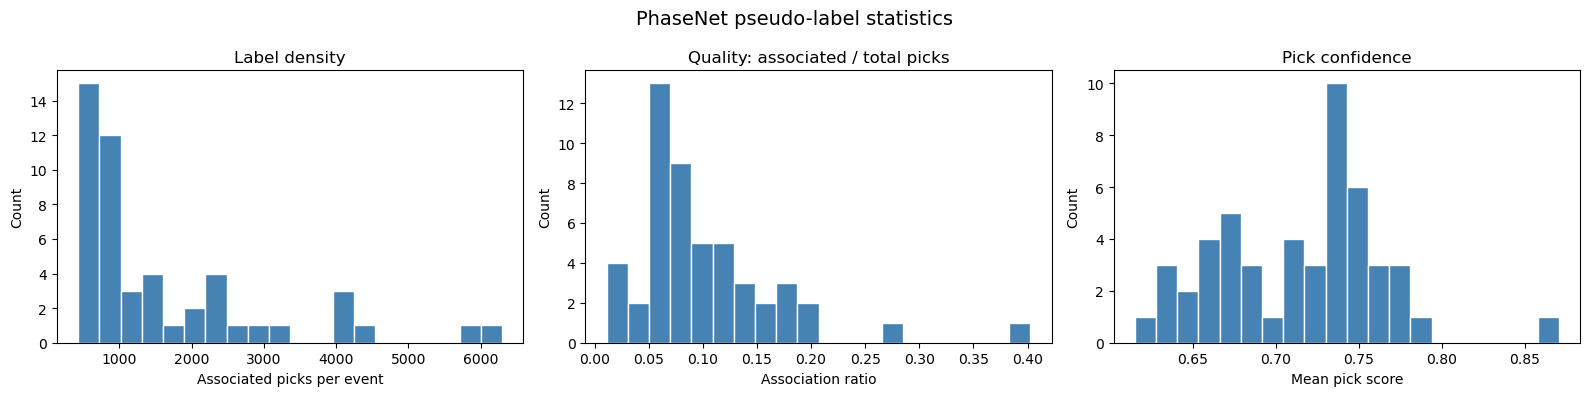

In [7]:
# Plot label statistics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(stats_df["associated_picks"], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Associated picks per event")
ax.set_ylabel("Count")
ax.set_title("Label density")

ax = axes[1]
ax.hist(stats_df["assoc_ratio"], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Association ratio")
ax.set_ylabel("Count")
ax.set_title("Quality: associated / total picks")

ax = axes[2]
ax.hist(stats_df["mean_score"], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean pick score")
ax.set_ylabel("Count")
ax.set_title("Pick confidence")

plt.suptitle("PhaseNet pseudo-label statistics", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Training Data Pipeline

Each training sample consists of:
- **Input**: DAS waveform crop `(1, nx_crop, nt_crop)` — typically `(1, 2048, 4096)`
- **Target**: Gaussian labels at pick locations `(3, nx_crop, nt_crop)` — P, S, and Noise channels

A key design choice from PhaseNet (Zhu & Beroza 2019) is using **Gaussian-shaped target functions** instead of hard labels (0/1). Each pick is represented as a Gaussian peak centered at the pick time with a width of ~60 samples. This has several advantages:
- **Encodes uncertainty**: the Gaussian spread naturally represents the inherent uncertainty in arrival-time picking
- **Smooth optimization**: provides gradients even when the model prediction is slightly offset from the true pick, leading to faster and more stable training
- **Multi-class formulation**: three channels (P, S, Noise) with `Noise = 1 - max(P, S)`, so the model learns to distinguish phases from background in a single forward pass

In [8]:
from phasenet.data.das import (
    Sample, Target, LabelConfig, generate_labels,
)

# Load waveform for the label event
h5_path = hf_hub_download(
    HF_REPO, f"arcata/data/{LABEL_EVENT}.h5", repo_type="dataset",
    local_dir="data/quakeflow_das",
)
with h5py.File(h5_path, "r") as fp:
    waveform = fp["data"][:]

nx, nt = waveform.shape

# Build targets from label picks
# Target uses p_picks and s_picks as lists of (channel_index, time_sample) tuples
p_picks_list = [(int(r["channel_index"]), int(r["phase_index"]))
                for _, r in labels[labels["phase_type"] == "P"].iterrows()]
s_picks_list = [(int(r["channel_index"]), int(r["phase_index"]))
                for _, r in labels[labels["phase_type"] == "S"].iterrows()]

target = Target(
    p_picks=p_picks_list,
    s_picks=s_picks_list,
    event_id=LABEL_EVENT,
)

sample = Sample(
    waveform=waveform.astype(np.float32)[np.newaxis, :, :],
    targets=[target],
    dt_s=dt_s,
    file_name=LABEL_EVENT,
)

print(f"Sample waveform: {sample.waveform.shape}")
print(f"P picks: {len(p_picks_list)}, S picks: {len(s_picks_list)}")

Sample waveform: (1, 7550, 52500)
P picks: 3042, S picks: 3042


In [9]:
# Generate Gaussian labels
config = LabelConfig(phase_width=60, event_width=150)
label_dict = generate_labels(sample, config=config)

phase_labels = label_dict["phase_pick"]  # (3, nx, nt) — Noise, P, S

print(f"Label shapes:")
for key, val in label_dict.items():
    print(f"  {key}: {val.shape}")

Label shapes:
  phase_pick: (3, 7550, 52500)
  phase_mask: (1, 7550, 52500)
  event_center: (1, 7550, 52500)
  event_time: (1, 7550, 52500)
  event_center_mask: (1, 7550, 52500)
  event_time_mask: (1, 7550, 52500)


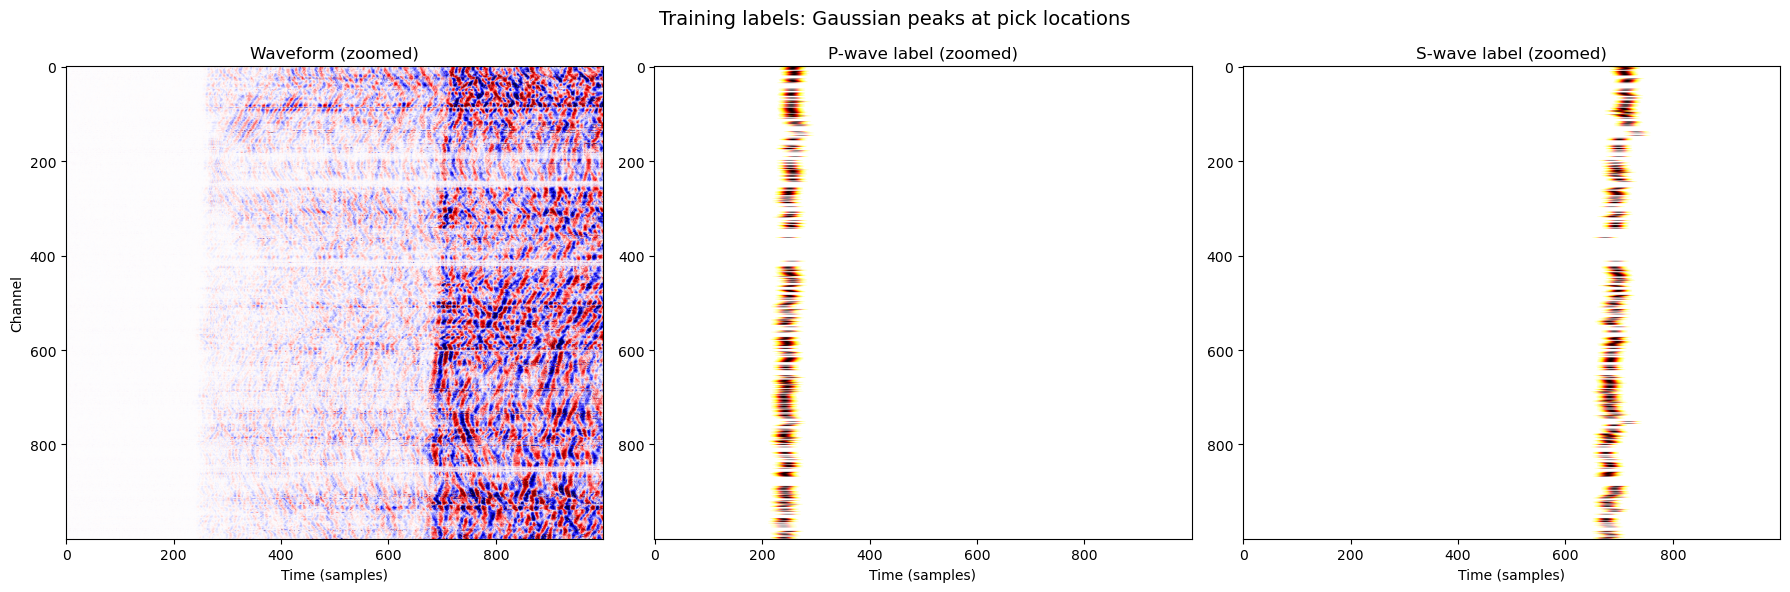

In [10]:
# Visualize training labels: zoomed view of Gaussian peaks at pick locations
p_labels = labels[labels["phase_type"] == "P"]
med_t = int(p_labels["phase_index"].astype(int).median()) + 250  # shift to center P and S
med_ch = int(p_labels["channel_index"].astype(int).median())

t_slice = slice(max(0, med_t - 500), min(nt, med_t + 500))
ch_slice = slice(max(0, med_ch - 500), min(nx, med_ch + 500))
vmax = np.percentile(np.abs(waveform[ch_slice, t_slice]), 99)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
ax.imshow(waveform[ch_slice, t_slice], aspect="auto", cmap="seismic",
          vmin=-vmax, vmax=vmax)
ax.set_title("Waveform (zoomed)")
ax.set_ylabel("Channel")

ax = axes[1]
ax.imshow(phase_labels[1, ch_slice, t_slice], aspect="auto", cmap="hot_r", vmin=0, vmax=1)
ax.set_title("P-wave label (zoomed)")

ax = axes[2]
ax.imshow(phase_labels[2, ch_slice, t_slice], aspect="auto", cmap="hot_r", vmin=0, vmax=1)
ax.set_title("S-wave label (zoomed)")

for ax in axes:
    ax.set_xlabel("Time (samples)")

plt.suptitle("Training labels: Gaussian peaks at pick locations", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Training Configuration

The training script `train.py` handles the full training loop. Key configuration:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `--model` | `phasenet_das_plus` | DAS model with event detection head |
| `--nx` / `--nt` | 2048 / 4096 | Crop size for training patches |
| `--batch-size` | 2 | Small batch due to large crop size |
| `--lr` | 1e-4 | Learning rate |
| `--max-iters` | 50000 | Total training iterations |

**Data augmentation** is important for training deep learning models on limited seismic data (Zhu et al. 2020). 
Data augmentation is an active area of research with significant room for improvement — designing augmentations that faithfully represent the variability of DAS recordings (e.g., varying noise environments, cable coupling, instrument responses) remains open.

**Note on hyperparameters**: The values above are reasonable defaults, but may not be optimal. The learning rate, batch size, crop size, and augmentation parameters all interact and can be tuned further. 
The semi-supervised nature of this approach means that hyperparameter tuning is especially impactful — better training leads to better picks, which become better labels for the next iteration.

In [ ]:
# The training command (after pip install phasenet)
train_cmd = """
phasenet-train \
    --model phasenet_das_plus \
    --dataset-type das \
    --data-path data/quakeflow_das/arcata/data \
    --label-path data/quakeflow_das/arcata/phasenet/picks \
    --label-list data/quakeflow_das/arcata/phasenet/labels.txt \
    --output-dir output/train_das_arcata \
    --nx 2048 --nt 4096 \
    --batch-size 1 --num-patch 16 --workers 0 \
    --max-iters 50000 \
    --lr 1e-4 --weight-decay 0.01 \
    --model-ema --model-ema-decay 0.999 --model-ema-steps 1 \
    --eval-interval 1000 --plot-interval 100 --save-interval 1000
"""
print("Training command:")
print(train_cmd)

In [ ]:
# # Uncomment to run training (requires GPU, takes several hours)
# # First download all label + data files from Hugging Face
# from tqdm.auto import tqdm
# for eid in tqdm(label_ids, desc="Downloading labels & data"):
#     hf_hub_download(HF_REPO, f"arcata/phasenet/picks/{eid}.parquet",
#                     repo_type="dataset", local_dir="data/quakeflow_das")
#     hf_hub_download(HF_REPO, f"arcata/data/{eid}.h5",
#                     repo_type="dataset", local_dir="data/quakeflow_das")
# # Then run training
# !{train_cmd}

## 6. Results

After training, the PhaseNet-DAS model produces dramatically cleaner picks than the original PhaseNet — fewer false positives on noise, and more detections on weak events.

Browse prediction figures for all 2,467 events comparing PhaseNet vs PhaseNet-DAS-Plus: [Google Drive](https://drive.google.com/drive/folders/1natqPKvg0q07AxLWFOSEpTEcE1OTzt2h?usp=sharing)

## The Iterative Loop

The semi-supervised training can be repeated to progressively improve the model:

| Iteration | Model | Predict | Associate | Train |
|-----------|-------|---------|-----------|-------|
| 0 | PhaseNet (seismic) | Initial picks on DAS | Filter to associated picks | PhaseNet-DAS v1 |
| 1 | PhaseNet-DAS v1 | Better picks (fewer false, more weak events) | Cleaner + more labels | PhaseNet-DAS v2 |
| 2 | PhaseNet-DAS v2 | Better picks | Cleaner + more labels | PhaseNet-DAS v3 |

Each iteration improves because the DAS model learns spatiotemporal patterns that reduce false picks and detect weaker events, producing higher-quality labels for the next round. In practice, 2-3 iterations are sufficient for convergence (Zhu et al. 2023).

## Summary

| Step | What | Why |
|------|------|-----|
| 1. Initial picks | Run PhaseNet (seismic) on DAS | Get approximate phase arrivals |
| 2. Association | P-S pairing + histogram clustering | Filter false picks, keep only consistent events |
| 3. Label generation | Associated picks → Gaussian targets | Create supervised training data |
| 4. Train | PhaseNet-DAS-Plus on labels | Learn DAS-specific spatiotemporal patterns |
| 5. Iterate | Re-predict → re-label → re-train | Progressively improve quality |

The key insight: **association is the bridge between unsupervised detection and supervised training**. By requiring physical consistency (P-S pairs, clustered origin times), we automatically filter out noise and false picks without manual labeling.

---

**Back to:** [Lab 2a: Inference](lab2a_phasenet_das_inference.ipynb) | [Lab 2b: Association](lab2b_pick_association.ipynb)